# Flight Ticket Price Prediction

This Dataset contains information about flight ticket booking records of indias top cities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

 importing Dataset and creating DataFrame of name df

In [2]:
df=pd.read_csv("flights_data.csv")

In [3]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


-- drop The unnecessory column with name unnamed.
 
-- flight name is not important for analysis

In [4]:
df=df.drop(["Unnamed: 0"],axis=1)
df=df.drop(["flight"],axis=1)


In [5]:
df.rename(columns={"class":"class_ct"}, inplace=True)

In [6]:
df.shape

(300153, 10)

-- The DataSet Contains 300153 rows i.e each columnn of dataframe contains **300153** datapoints and **10** columns i.e 10 features

In [7]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class_ct,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class_ct          300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


--There is not any null value and each column contains similar number of records. the featurs airline, source city,   departure_time, stops, arrival_time, destination_city, class  have object datatype and duration have float and days_left and     price are int64

### Featching Unique values from Dataframe and value counts for each category in column 

In [9]:
airline_count=df["airline"].value_counts().sort_values(ascending=False)
source_cities=df["source_city"].value_counts()
departure_times=df["departure_time"].value_counts()
stops_=df["stops"].value_counts()
arrival_times=df["arrival_time"].value_counts()
destination_cities=df["destination_city"].value_counts()
class_category=df["class_ct"].value_counts()
g="-------------------------------------------------"

In [10]:
print(f" {airline_count} \n{g}\n {source_cities} \n {g} \n {departure_times} \n{g}\n {stops_} \n{g}\n {arrival_times} \n{g}\n {destination_cities} \n{g}\n{class_category}")

 Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: airline, dtype: int64 
-------------------------------------------------
 Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: source_city, dtype: int64 
 ------------------------------------------------- 
 Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: departure_time, dtype: int64 
-------------------------------------------------
 one            250863
zero            36004
two_or_more     13286
Name: stops, dtype: int64 
-------------------------------------------------
 Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: arrival_time, dtype: int64 
-------------------------------------------------
 Mumbai 

## Exploratory Data Analysis(EDA)

#### 1.  Number of Passengers Per Airline 

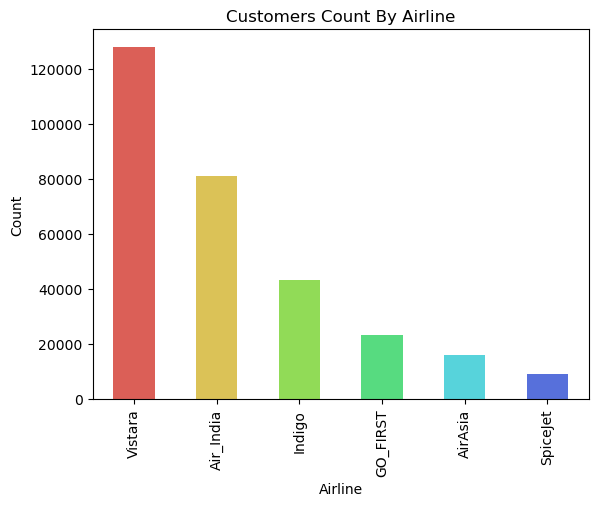

In [11]:
#Creating Bar Plot of Airline Counts
colors=sns.color_palette("hls",8)
airline_count.plot(kind='bar',color=colors)
plt.title("Customers Count By Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.show()

-- From Above Bar Plot , The Most Vistara Airline have Maximum Number and Spicejet have least Number of Customers.

#### 2. Average ticket price for each airline

In [12]:
color1=sns.color_palette("Set2")

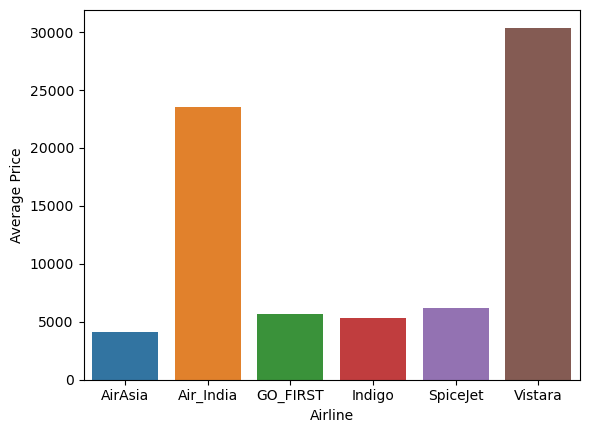

In [13]:
average_price = df.groupby('airline')['price'].mean().reset_index()
sns.barplot(x="airline",y="price", data=average_price)
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.show()

-- Most expensive price of tickets = Vistara and  least price of tickets =AirAsia


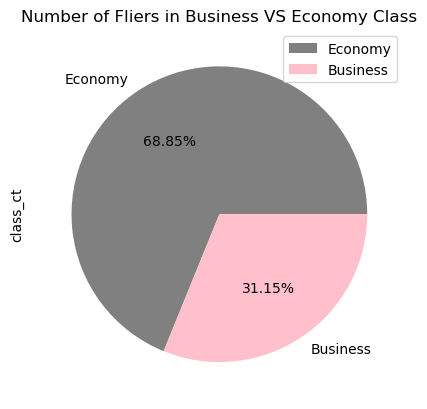

In [14]:
color3=["grey","pink"]
class_category.plot(kind='pie', colors=color3,autopct='%1.2f%%')
plt.title("Number of Fliers in Business VS Economy Class")
plt.legend()
plt.show()

Data Set Contains **68%** of Economy Class Customers and **31.15%** of Business Class customers

#### 3. Tickets Prices Based on Airlines

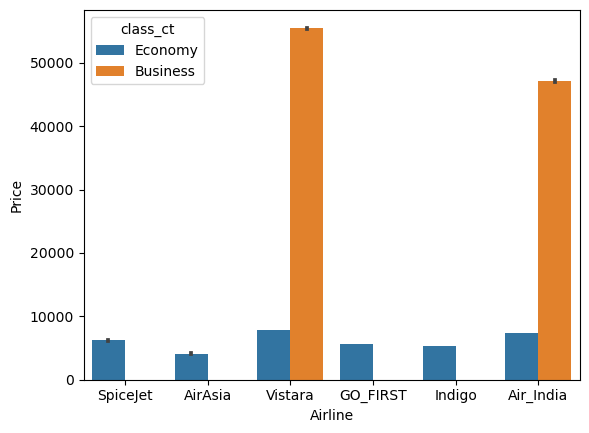

In [15]:
sns.barplot(x="airline",y="price",hue="class_ct",data=df)
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()

-- Price varies with Airlines. Clearly, in Economy Class Vistara is the most expensive and Air Asia is the least expensive whereas, in the Business Class, Vistara is the most expensive and Air India is the least expensive

#### 4. Ticket prices based on class

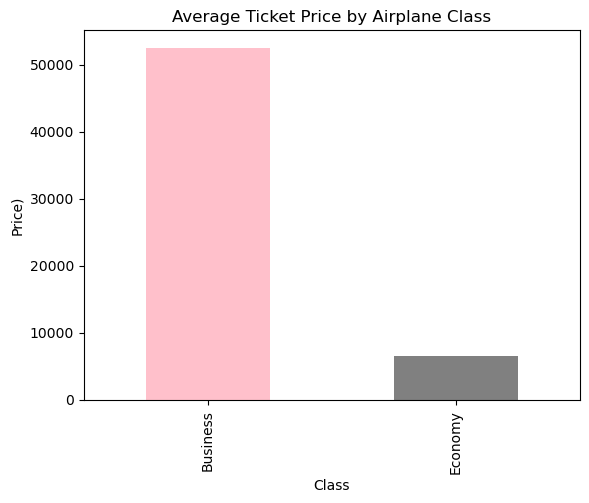

In [16]:
class_prices = df.groupby('class_ct')['price'].mean()
class_prices.plot(kind='bar', color=['pink', 'grey'])
plt.title("Average Ticket Price by Airplane Class")
plt.xlabel("Class")
plt.ylabel("Price)")
plt.show()

-- Here we see That Business class have More Expensive Ticket Prices as Compare To Economy Class

-- It is a well-known fact that Business Class tickets are generally more expensive than Economy Class tickets. This is due to the additional amenities and perks that come with Business Class, such as more legroom, better food, and priority boarding.

#### 5. the price affected when tickets are bought in just 1 or 2 days before departure

<AxesSubplot:xlabel='days_left', ylabel='price'>

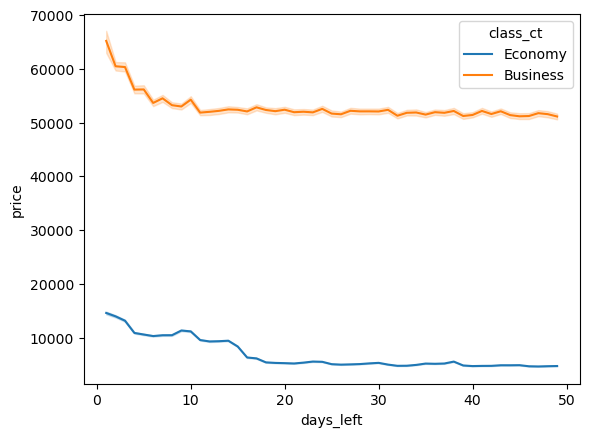

In [17]:
sns.lineplot(data=df, x='days_left', y='price', hue='class_ct')

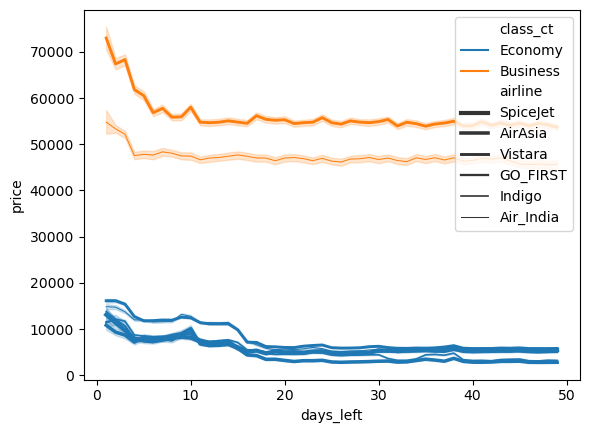

In [18]:
sns.lineplot(data=df, x='days_left', y='price', hue='class_ct', size='airline')
plt.legend()

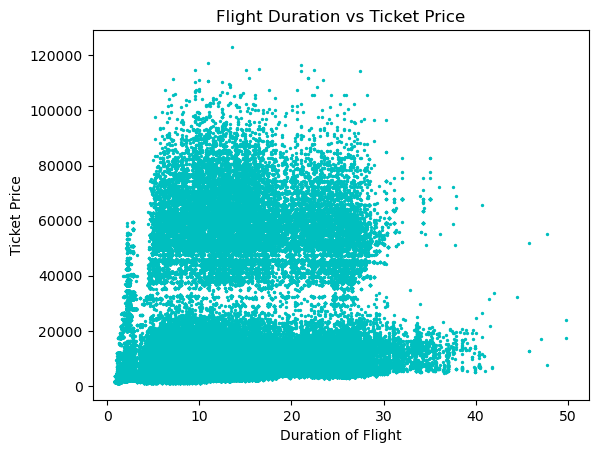

In [19]:
plt.scatter(df['duration'], df['price'], s=2, color= 'c')


plt.title("Flight Duration vs Ticket Price")
plt.xlabel("Duration of Flight")
plt.ylabel("Ticket Price")
plt.show()


-- Based on above Graph, prices of airline tickets rise when purchased just 1-2 days Before the scheduled departure, with Business class tickets being subject to even higher price hikes compared to Economy Class Tickets

-- the best time to book tickets of Economy class is at least three weeks prior to the departure date. And for business class tickets to book them at least ten days before the departure

#### 6. Ticket price Based on Deparature time and arrival time

<AxesSubplot:xlabel='arrival_time', ylabel='price'>

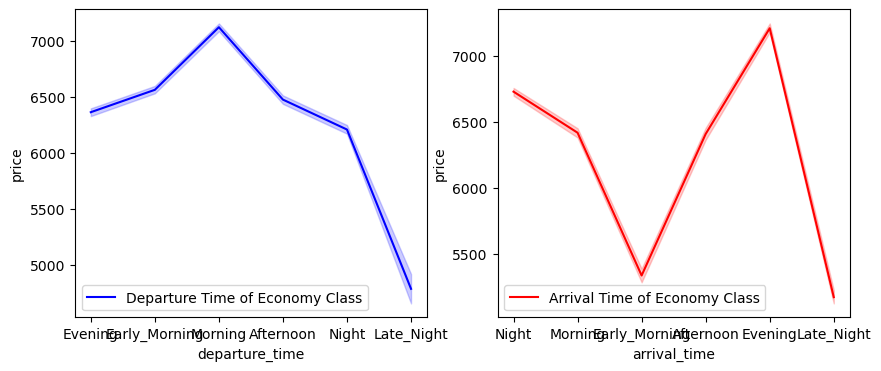

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(ax=axs[0],data=df.loc[df["class_ct"]=="Economy"], x='departure_time', y='price', color='blue', label='Departure Time of Economy Class')

sns.lineplot(ax=axs[1],data=df.loc[df["class_ct"]=="Economy"], x='arrival_time', y='price', color='red', label='Arrival Time of Economy Class')

<AxesSubplot:xlabel='arrival_time', ylabel='price'>

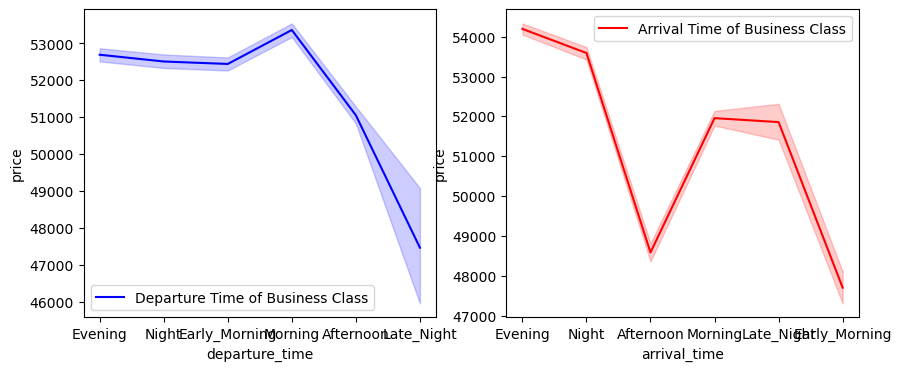

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(ax=axs[0],data=df.loc[df["class_ct"]=="Business"], x='departure_time', y='price', color='blue', label='Departure Time of Business Class')

sns.lineplot(ax=axs[1],data=df.loc[df["class_ct"]=="Business"], x='arrival_time', y='price', color='red', label='Arrival Time of Business Class')

-- It is evident that the price tends to be higher for the Economy class when the departure time is in the morning, and it decreases with the day progresses

-- the price tends to be higher when the arrival time is in the afternoon or evening, with lower prices in the morning or at night.

#### 7. Ticket Prices Varies with the Source and Destination city

<AxesSubplot:xlabel='source_city', ylabel='price'>

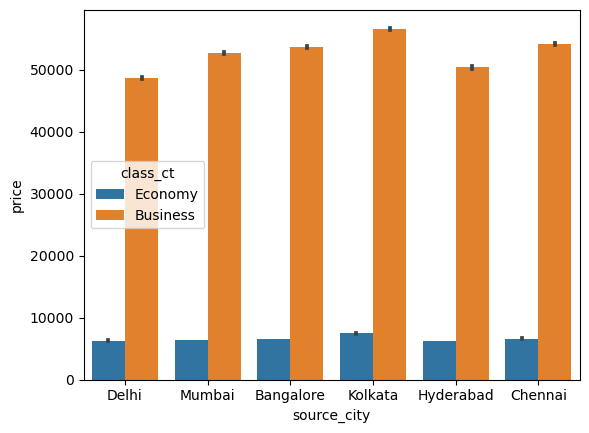

In [22]:
sns.barplot(data=df, x="source_city",y="price",hue="class_ct")

-- The data shows that flights departing from Delhi have the least expensive tickets, followed by Hyderabad, Mumbai, Bangalore, Chennai, and Kolkata

<AxesSubplot:xlabel='duration', ylabel='price'>

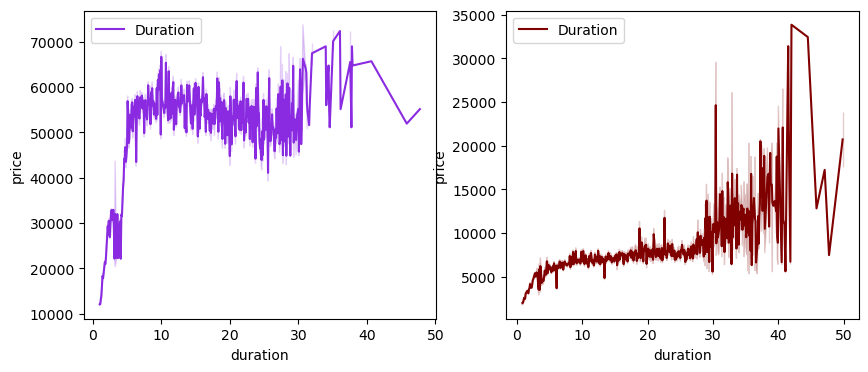

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(ax=axs[0],data=df.loc[df["class_ct"]=="Business"], x='duration', y='price', color='blueviolet', label='Duration')
sns.lineplot(ax=axs[1],data=df.loc[df["class_ct"]=="Economy"], x='duration', y='price', color='maroon', label='Duration')

<AxesSubplot:xlabel='duration', ylabel='price'>

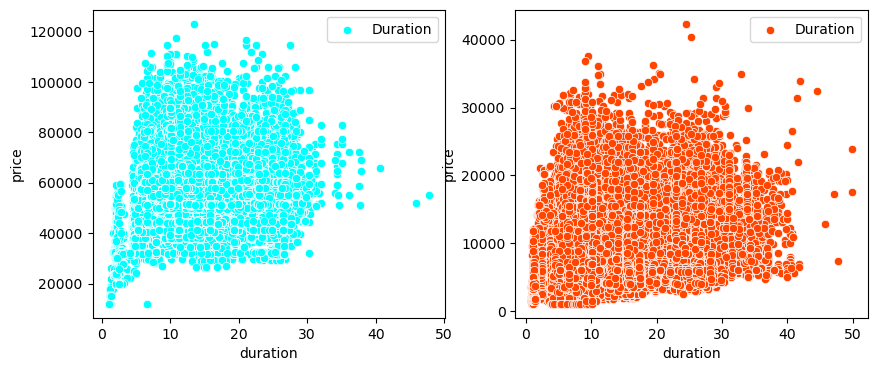

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(ax=axs[0],data=df.loc[df["class_ct"]=="Business"], x='duration', y='price', color='cyan', label='Duration')
sns.scatterplot(ax=axs[1],data=df.loc[df["class_ct"]=="Economy"], x='duration', y='price', color='orangered', label='Duration')


--flights with longer durations tend to be more expensive than those with moderate or short durations, regardless of whether it is economy or business class.

-- For economy class fliers, short distance flights surprisingly have costlier tickets than longer distance flights, 

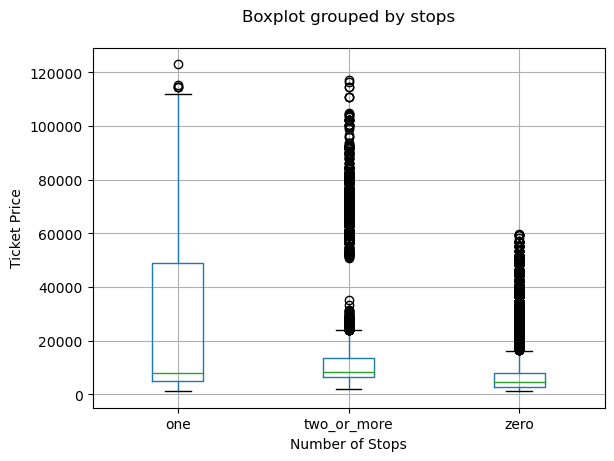

In [25]:
df.boxplot(column='price', by='stops')

plt.title("")
plt.xlabel("Number of Stops")
plt.ylabel("Ticket Price")
plt.show()

<AxesSubplot:xlabel='stops', ylabel='price'>

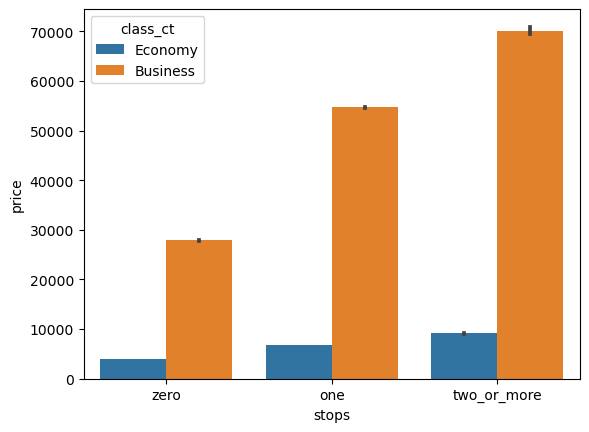

In [26]:
sns.barplot(data=df,x="stops",y="price",hue="class_ct")

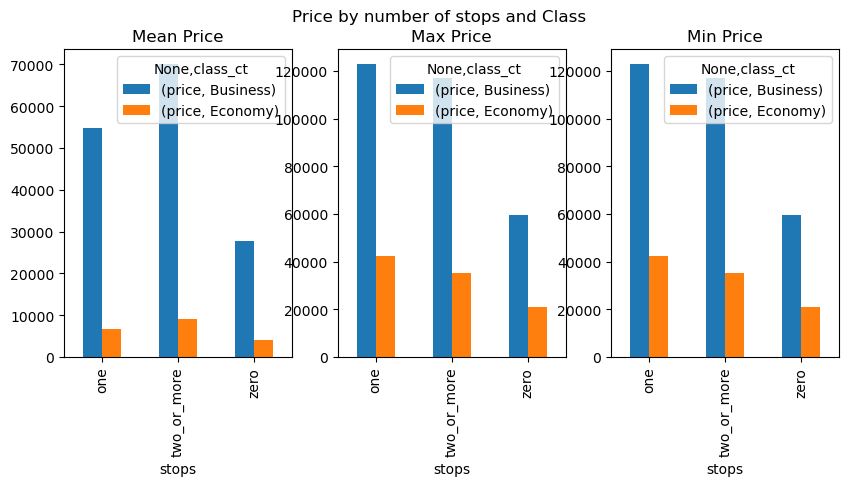

In [27]:
mean_stops = df.groupby(["stops", 'class_ct']).price.mean().to_frame()
max_stops = df.groupby(["stops", 'class_ct']).price.max().to_frame()
min_stops = df.groupby(["stops", 'class_ct']).price.max().to_frame()

fig, axs = plt.subplots(1, 3, figsize=(10, 4))
mean_stops.unstack().plot(kind='bar', ax=axs[0], title='Mean Price')
max_stops.unstack().plot(kind='bar', ax=axs[1], title='Max Price')
min_stops.unstack().plot(kind='bar', ax=axs[2], title='Min Price')
plt.suptitle('Price by number of stops and Class')
plt.show()

-- it was found that flights with two or more stops have the highest average prices, followed by one-stop flights and non-stop flights. one-stop flights have the highest maximum ticket prices, while two or more stops and non-stop flights have lower maximum prices.

# Conclusion

### There are several factors to consider before making ticket purchase
 -- One of the most important factors is the timing of your flight
 
 -- flights which arrive at late night times tend to be cheaper than those that arrive during peak hours
 
 -- another factors is the number of stops flights takes, flights with more stops is cheaper than fewer stops
 
 -- on conclusion we got these above important factors which we can consider.

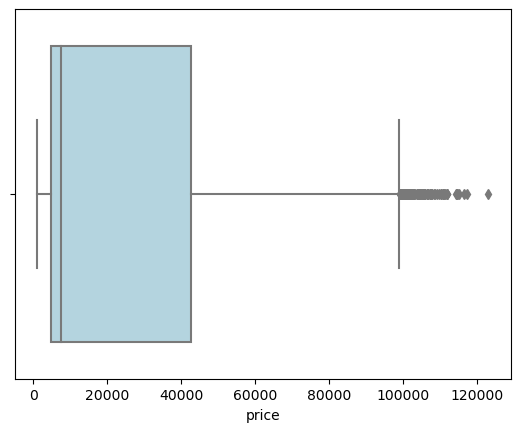

In [28]:
sns.boxplot(df["price"],color= "lightblue")
plt.show()

median is closer to the bottom of the box, and whisker is shorter on the lower end of the box then the distribution is positively skewed (skewed right).

#### identifying outliets with interquartile Range(IQR)


In [29]:
Q1=df.price.quantile(0.25)
Q3=df.price.quantile(0.75)
IQR = Q3-Q1
print(Q1)
print(Q3)
print(IQR)

4783.0
42521.0
37738.0


<AxesSubplot:>

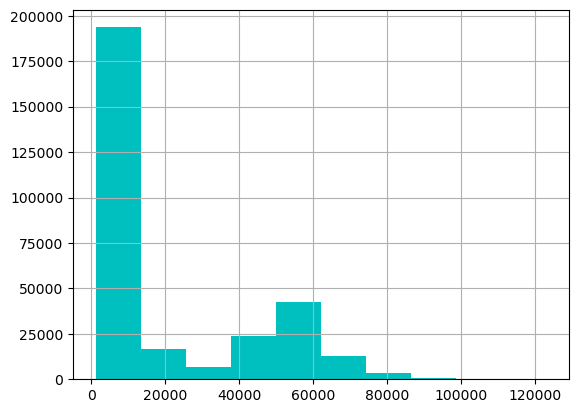

In [30]:
df["price"].hist(color="c")

<AxesSubplot:xlabel='price', ylabel='Density'>

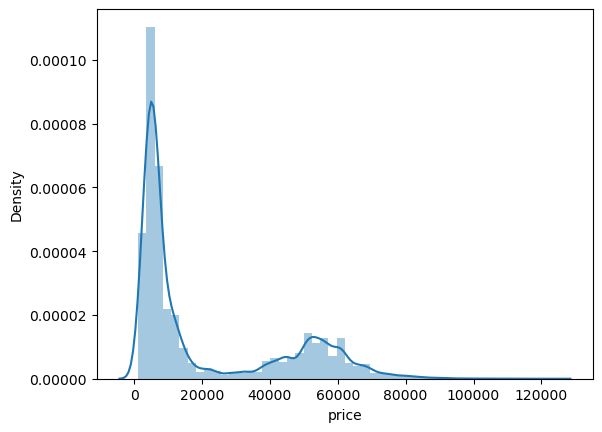

In [31]:
sns.distplot(df["price"])

### Performing target encoding for all categorical variables:

In [9]:
from sklearn.preprocessing import OrdinalEncoder


In [10]:
oe=OrdinalEncoder() 
df[["airline","source_city","departure_time","stops","arrival_time","destination_city","class_ct"]]=oe.fit_transform(df[["airline","source_city","departure_time","stops","arrival_time","destination_city","class_ct"]])
df.head()


,airline,source_city,departure_time,stops,arrival_time,destination_city,class_ct,duration,days_left,price
0,4.0,2.0,2.0,2.0,5.0,5.0,1.0,2.17,1,5953
1,4.0,2.0,1.0,2.0,4.0,5.0,1.0,2.33,1,5953
2,0.0,2.0,1.0,2.0,1.0,5.0,1.0,2.17,1,5956
3,5.0,2.0,4.0,2.0,0.0,5.0,1.0,2.25,1,5955
4,5.0,2.0,4.0,2.0,4.0,5.0,1.0,2.33,1,5955


In [11]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class_ct,duration,days_left,price
0,4.0,2.0,2.0,2.0,5.0,5.0,1.0,2.17,1,5953
1,4.0,2.0,1.0,2.0,4.0,5.0,1.0,2.33,1,5953
2,0.0,2.0,1.0,2.0,1.0,5.0,1.0,2.17,1,5956
3,5.0,2.0,4.0,2.0,0.0,5.0,1.0,2.25,1,5955
4,5.0,2.0,4.0,2.0,4.0,5.0,1.0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,5.0,1.0,4.0,0.0,2.0,3.0,0.0,10.08,49,69265
300149,5.0,1.0,0.0,0.0,5.0,3.0,0.0,10.42,49,77105
300150,5.0,1.0,1.0,0.0,5.0,3.0,0.0,13.83,49,79099
300151,5.0,1.0,1.0,0.0,2.0,3.0,0.0,10.00,49,81585


### Data Preprocessing - Data Scaling

# Feature engineering:

<AxesSubplot:>

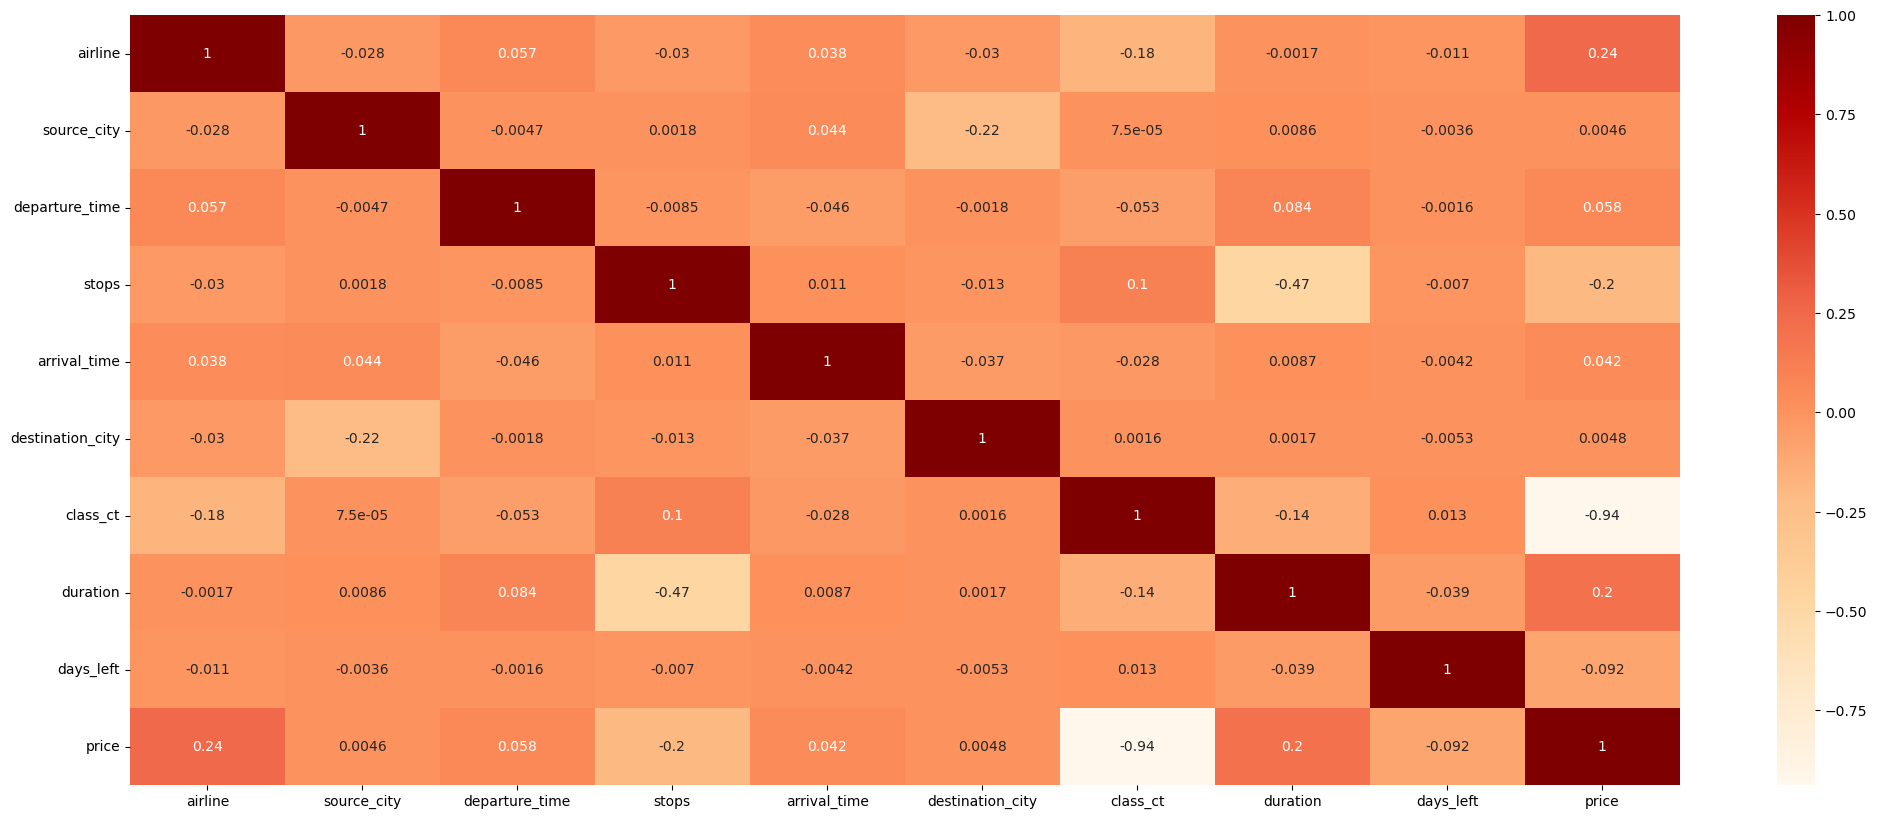

In [170]:
plt.figure(figsize=(25,10))
corl=df.corr()
corl
sns.heatmap(corl,cmap="OrRd",annot=True)

In [171]:
corl=df.corr()
corl

,airline,source_city,departure_time,stops,arrival_time,destination_city,class_ct,duration,days_left,price
airline,1.000000,-0.028350,0.056885,-0.029838,0.037714,-0.030172,-0.178862,-0.001651,-0.010678,0.243358
source_city,-0.028350,1.000000,-0.004688,0.001819,0.044153,-0.222935,0.000075,0.008619,-0.003568,0.004594
departure_time,0.056885,-0.004688,1.000000,-0.008518,-0.046282,-0.001761,-0.053340,0.084348,-0.001597,0.058319
stops,-0.029838,0.001819,-0.008518,1.000000,0.010515,-0.012846,0.100262,-0.473860,-0.007047,-0.202620
arrival_time,0.037714,0.044153,-0.046282,0.010515,1.000000,-0.037431,-0.027647,0.008679,-0.004191,0.042043
destination_city,-0.030172,-0.222935,-0.001761,-0.012846,-0.037431,1.000000,0.001603,0.001736,-0.005323,0.004795
class_ct,-0.178862,0.000075,-0.053340,0.100262,-0.027647,0.001603,1.000000,-0.138710,0.013039,-0.937860
duration,-0.001651,0.008619,0.084348,-0.473860,0.008679,0.001736,-0.138710,1.000000,-0.039157,0.204222
days_left,-0.010678,-0.003568,-0.001597,-0.007047,-0.004191,-0.005323,0.013039,-0.039157,1.000000,-0.091949
price,0.243358,0.004594,0.058319,-0.202620,0.042043,0.004795,-0.937860,0.204222,-0.091949,1.000000


In [172]:
#Correlation with target variable price
cor_target = abs(corl["price"])

relevant_features = cor_target
relevant_features 


airline             0.243358
source_city         0.004594
departure_time      0.058319
stops               0.202620
arrival_time        0.042043
destination_city    0.004795
class_ct            0.937860
duration            0.204222
days_left           0.091949
price               1.000000
Name: price, dtype: float64

### According to Pearsons correlation, our top 4 relevant features are: class_ct, airline, stops and duration.
### class_category is highly correlated and proportion to the price 

# Prediction Models

## Building, running and evaluating our models:

### Following Regression Techniques we use for Build Train and Test And Run Our Machine learning Model

1. LinearRegression
2. Ridge
3. KNeighborsRegressor
4. GradientBoostingRegressor
5. AdaBoostRegressor
6. RandomForestRegressor
7. XGBRegressor

In [12]:
#Importing Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

In [19]:
#Importing mean_squared_error,mean_absolute_error,r2_score to check how our model is accurate
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

## Split the data into training and testing sets:

In [13]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=1)

# Linear Regression accuracy : 90.53%

In [16]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
ypred=lr_model.predict(x_test)

In [17]:
ypred

array([ 3736.95124043,  8975.79716518,  5145.88400305, ...,
       52675.90909213,  6675.93041497, 10691.64611493])

In [20]:
mae=mean_absolute_error(y_test,ypred)
mse=mean_squared_error(y_test,ypred)
score = lr_model.score(x_test,y_test)
rmse=np.sqrt(mse)
r2=r2_score(y_test,ypred)

print("Mean Absolute Error     : ",mae)
print("Mean Squared Error      : ",mse)
print("Root Mean Squared Error : ",rmse)
print("Accuracy of Model       : ",score)
print("R-squared               : ",r2)

Mean Absolute Error     :  4624.472195523093
Mean Squared Error      :  48547659.85151397
Root Mean Squared Error :  6967.615076302218
Accuracy of Model       :  0.905248464004139
R-squared               :  0.905248464004139


# Polynomial regression accuracy : 96.08 % at degree = 5

In [21]:
from sklearn.preprocessing import PolynomialFeatures

In [22]:
polyreg=PolynomialFeatures(degree=1)
polyx=polyreg.fit_transform(x)

In [24]:
for i in range(1,6):
    polyreg=PolynomialFeatures(degree=i)
    polyxtrain=polyreg.fit_transform(x_train)
    polyxtest=polyreg.transform(x_test)
    modelp=LinearRegression()
    modelp.fit(polyxtrain,y_train)
    ypred=modelp.predict(polyxtest)
    mae=mean_absolute_error(y_test,ypred)
    mse=mean_squared_error(y_test,ypred)
    score = modelp.score(polyxtest,y_test)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,ypred)

    print("Degree                  : ",i)
    print("Mean Absolute Error     : ",mae)
    print("Mean Squared Error      : ",mse)
    print("Root Mean Squared Error : ",rmse)
    print("Accuracy of Model       : ",score)
    print("R-squared               : ",r2)
    print("----------------------------------------------------------------")


Degree                  :  1
Mean Absolute Error     :  4624.472195523091
Mean Squared Error      :  48547659.85151397
Root Mean Squared Error :  6967.615076302218
Accuracy of Model       :  0.905248464004139
R-squared               :  0.905248464004139
----------------------------------------------------------------
Degree                  :  2
Mean Absolute Error     :  3534.358765454457
Mean Squared Error      :  31758928.463339552
Root Mean Squared Error :  5635.506052107437
Accuracy of Model       :  0.9380154004809307
R-squared               :  0.9380154004809307
----------------------------------------------------------------
Degree                  :  3
Mean Absolute Error     :  3130.5575164026795
Mean Squared Error      :  26200513.778618082
Root Mean Squared Error :  5118.643744061319
Accuracy of Model       :  0.9488638807308574
R-squared               :  0.9488638807308574
----------------------------------------------------------------
Degree                  :  4
Mean Ab

# KNeighborsRegressoion  accuracy : 72.26 % at n_neighbors = 4

In [27]:
knr=KNeighborsRegressor(n_neighbors=4)
knr.fit(x_train,y_train)
ypred=knr.predict(x_test)
mae=mean_absolute_error(y_test,ypred)
mse=mean_squared_error(y_test,ypred)
score = knr.score(x_test,y_test)
rmse=np.sqrt(mse)
r2=r2_score(y_test,ypred)
    
print("k value                 : ",K)
print("Mean Absolute Error     : ",mae)
print("Mean Squared Error      : ",mse)
print("Root Mean Squared Error : ",rmse)
print("Accuracy of Model       : ",score)
print("R-squared               : ",r2)
print("---------------------------------------------------------")

k value                 :  20
Mean Absolute Error     :  8193.447439656178
Mean Squared Error      :  142111963.59550586
Root Mean Squared Error :  11921.07225024267
Accuracy of Model       :  0.7226369535576669
R-squared               :  0.7226369535576669
---------------------------------------------------------


# Gradient Boosting Regressoion accuracy = 98.72 % at n_estimators = 100 and max depth = 13

In [28]:
for j in range(1,20):
    for i in range(100,101):
        gbr=GradientBoostingRegressor(max_depth=j,n_estimators=i)
        gbr.fit(x_train,y_train)
        ypred=gbr.predict(x_test)
        mae=mean_absolute_error(y_test,ypred)
        mse=mean_squared_error(y_test,ypred)
        rmse=np.sqrt(mse)
        r2=r2_score(y_test,ypred)
        print(f"{j} {i} {mae} {mse} {rmse} {r2}")
        
   

1 100 4388.77727184083 45332971.54130329 6732.976425126059 0.9115226419165663
2 100 3181.9665749916467 27790099.00591119 5271.631531690278 0.94576145226483
3 100 2932.3459187800763 24047507.171653584 4903.825768892445 0.9530659511013567
4 100 2725.32125934473 21198568.78265768 4604.190350393615 0.95862628684443
5 100 2560.114065867494 18999287.381246798 4358.817199797073 0.9629186727495007
6 100 2357.3884156386175 16451547.148747936 4056.050683700579 0.9678911534228445
7 100 2124.999401070472 13790799.141338 3713.596523767492 0.9730841938571541
8 100 1932.422758824334 11738550.777361084 3426.1568524165796 0.9770896121476865
9 100 1734.9171458271683 9930204.236648405 3151.222657421783 0.9806190018828332
10 100 1524.1174901797551 7950838.179626419 2819.723067896282 0.9844821741711481
11 100 1421.553855340683 7430588.389788693 2725.9105615901435 0.9854975571337753
12 100 1308.398868100975 6756567.949966916 2599.3399065853077 0.9868130576576122
13 100 1223.6481406678602 6548159.381333573 2

# AdaBoost Regression  accuracy = 93.52 % at n_estimators  = 113

In [29]:
for i in range(100,120):
    adb=AdaBoostRegressor(n_estimators=i)
    adb.fit(x_train,y_train)
    ypred=adb.predict(x_test)
    mae=mean_absolute_error(y_test,ypred)
    mse=mean_squared_error(y_test,ypred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,ypred)
    print(f"{i} {mae} {mse} {rmse} {r2}")

100 3949.2617118180715 36790065.58111119 6065.481479743483 0.9281960194608632
101 3931.4140592106946 36976078.35230913 6080.795865041773 0.9278329742422109
102 4100.169523264725 39772907.08866451 6306.576495109253 0.9223743420548394
103 4082.3484544208136 38292203.847784966 6188.069476644955 0.9252642631520972
104 4013.016999462292 38017628.64778718 6165.843709322122 0.9258001576118041
105 3922.304322048891 36588831.36966502 6048.8702556481585 0.9285887726993871
106 4057.5353080375935 37636484.236157544 6134.858126815774 0.9265440455468478
107 4043.478134873431 38372910.2595209 6194.587174261163 0.9251067466724134
108 3809.6171896829064 35181562.545054786 5931.404769955831 0.9313353702305295
109 3927.6690815024053 35729360.2240094 5977.404137584258 0.9302662214465373
110 3863.8301821460905 35162834.79414263 5929.825865414821 0.9313719215940782
111 4128.0042398667265 39477677.18771546 6283.126386419062 0.9229505487488878
112 3981.967712944909 36885717.17061422 6073.361274501478 0.928009

# XGB Regressoion accuracy = 98.10 % at n_estimators = 200

In [30]:
for i in range(150,200):
    xgb=XGBRegressor( n_estimators=i)
    xgb.fit(x_train,y_train)
    ypred=xgb.predict(x_test)
    mae=mean_absolute_error(y_test,ypred)
    mse=mean_squared_error(y_test,ypred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,ypred)
    print(f"{i} {mae} {mse} {rmse} {r2}")

150 1876.6724969483541 10614579.55065786 3258.002386533481 0.9792832915231913
151 1876.047450299889 10604612.403028332 3256.4723863451277 0.9793027446245413
152 1874.0996100623076 10587867.112097839 3253.900292279688 0.9793354267773209
153 1872.9024332677548 10572391.428329892 3251.52140210239 0.9793656310098644
154 1872.1400378308365 10561413.795654051 3249.8328873426785 0.9793870562971144
155 1870.0922795764507 10547686.380392328 3247.7201819726292 0.9794138483955447
156 1869.4639511020705 10542017.628375998 3246.8473367831753 0.9794249122235926
157 1866.7120024283026 10518875.984225856 3243.281668962142 0.9794700782796991
158 1864.5096079478808 10502234.33894985 3240.7150968497444 0.9795025581449743
159 1861.8568583427127 10470236.966330895 3235.774554311671 0.9795650081211987
160 1860.7014661636654 10456982.43591819 3233.7257824246926 0.9795908772798636
161 1857.4812771244542 10415582.595093763 3227.318173823858 0.9796716782601805
162 1854.5361461428115 10387533.747318542 3222.9697

# Random Forest Regressor accuracy = 96.44% max_depth = 10, n_estimators = 101

In [31]:
for i in range(100,120):
    rfr = RandomForestRegressor(max_depth=10,n_estimators=i,random_state = 1) 
    rfr.fit(x_train,y_train)
    ypred=rfr.predict(x_test)
    mae=mean_absolute_error(y_test,ypred)
    mse=mean_squared_error(y_test,ypred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,ypred)
    print(f" {i} {mae} {mse} {rmse} {r2}")


 100 2408.481851905722 18232178.316931892 4269.915492949702 0.9644158563901231
 101 2408.0896911282866 18224303.1027251 4268.993218866141 0.9644312266189801
 102 2408.0862016601764 18227372.098408148 4269.352655661997 0.964425236792574
 103 2407.9746152043326 18226495.09714795 4269.249945499554 0.9644269484552315
 104 2408.2745357386702 18231495.836704224 4269.835574902648 0.964417188401801
 105 2408.464680761849 18237144.227578316 4270.4969532337 0.9644061643130424
 106 2408.5898463391527 18238130.590916805 4270.612437451659 0.9644042392060104
 107 2408.588748913881 18240745.220263205 4270.918545262039 0.9643991361763815
 108 2408.7574440901108 18243512.087529853 4271.2424524404905 0.9643937360206538
 109 2408.3971902038493 18236942.55019265 4270.473340297613 0.9644065579312339
 110 2408.514949711599 18238772.90146711 4270.687638011836 0.9644029855943757
 111 2408.116706933168 18232329.921048712 4269.933245502641 0.9644155605010323
 112 2408.408098922554 18235187.65648406 4270.2678670

# DecisionTree Regressoion   accuracy : 98.38 % min sample split = 10 min sample leaf = 7

In [32]:
for i in range(1,21):
    dt = DecisionTreeRegressor(min_samples_split=10, min_samples_leaf=i,random_state = 1) 
    dt.fit(x_train,y_train)
    ypred=dt.predict(x_test)
    mae=mean_absolute_error(y_test,ypred)
    mse=mean_squared_error(y_test,ypred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,ypred)
    print(f" {i} {mae} {mse} {rmse} {r2}")

 1 1144.6957740881496 9127697.59368201 3021.20796928679 0.9821852717566133
 2 1140.3155538091034 8613195.651664445 2934.8246372934186 0.9831894365181718
 3 1159.0117872168164 8492629.783339467 2914.21169157964 0.9834247475763651
 4 1175.0306986165613 8460465.330987234 2908.687905394326 0.9834875236457814
 5 1200.132139082638 8466749.148392372 2909.7678856555503 0.9834752593810799
 6 1221.752903227586 8430035.710641434 2903.452377884203 0.9835469138053968
 7 1237.035032468027 8297292.49950595 2880.5021262804075 0.9838059916515088
 8 1254.9327951779792 8322224.353570606 2884.826572529206 0.9837573316033196
 9 1270.3531880685848 8306893.508549548 2882.168195742495 0.9837872531508938
 10 1289.2769394505497 8359160.823677793 2891.221337718334 0.9836852418818454
 11 1306.3571973308444 8424767.019123117 2902.544921120622 0.9835571968265677
 12 1319.5905931777343 8458759.4760628 2908.3946561742273 0.9834908530003738
 13 1336.5090055930418 8559836.454818131 2925.7198182358698 0.9832935788367956

# Results

# All Performed Regression Models Gives Above 90 % Accuracy

Checking Results of Prediction Models 

Prediction with Gradient Boosting Regression Model

In [112]:
gbr.predict([x])

array([41052.30433213])

In [108]:
knr.predict([x])

array([5974.])

In [135]:
def prediction():
    i=int(input("Enter details : "))
    x=df.iloc[i][:-1]
    print(x)
    print("-----------------------")
    y=df.iloc[i][-1]
    print("price           : ",y)
    print("-----------------------")
    price=gbr.predict([x])
    print("Predicted Price : ",price)
    

In [136]:
prediction()

Enter details : 5
airline             5.00
source_city         2.00
departure_time      4.00
stops               2.00
arrival_time        0.00
destination_city    5.00
class_ct            1.00
duration            2.33
days_left           1.00
Name: 5, dtype: float64
-----------------------
price           :  5955.0
-----------------------
Predicted Price :  [5956.0544454]
